# Phase 5.5: Model Explainability (SHAP)

This notebook generates global, city-wise, and local SHAP explanations for the final baseline XGBoost classifier to understand the features driving urban growth predictions.

In [1]:
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shap

%matplotlib inline
sns.set_theme(style='whitegrid')

## 1. Load Model & Preprocessed Data

In [2]:
data_dir = Path('../data/ml')
models_dir = Path('../models')

# Load model
with open(models_dir / 'xgboost_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load test set features and drop target leakage column
X_test = pd.read_csv(data_dir / 'X_test.csv')
if 'urban_change_index' in X_test.columns:
    X_test_model = X_test.drop(columns=['urban_change_index'])
else:
    X_test_model = X_test.copy()

feature_names = list(X_test_model.columns)
print(f'Test features count: {len(feature_names)}')
print('X_test shape:', X_test_model.shape)

Test features count: 24
X_test shape: (919, 24)


## 2. Initialize TreeExplainer & Calculate SHAP values

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_model)

print('TreeExplainer base values shape:', explainer.expected_value)
print('SHAP values shape:', shap_values.shape)
# Classes: 0 = High, 1 = Low, 2 = Medium

TreeExplainer base values shape: [0.5595136, 0.37389597, 0.63494635]
SHAP values shape: (919, 24, 3)


## 3. Global Explainability
### SHAP Beeswarm Plot (High Growth Category)

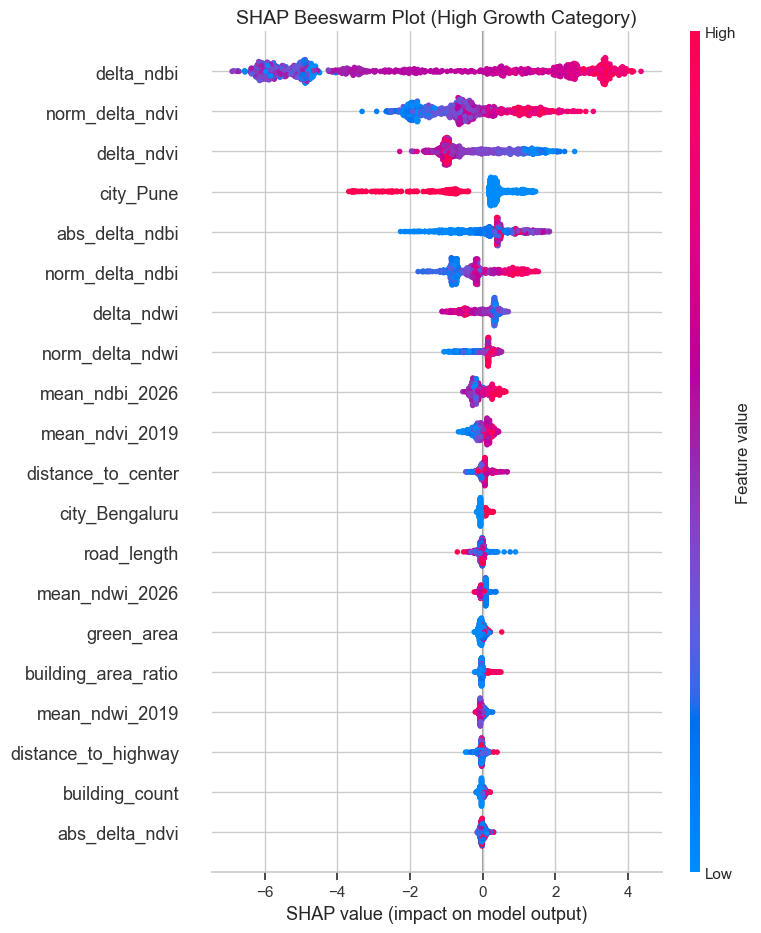

In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[:, :, 0], X_test_model, show=False)
plt.title('SHAP Beeswarm Plot (High Growth Category)', fontsize=14)
plt.tight_layout()
plt.show()

### SHAP Bar Plot (Overall Stacked Feature Importance)

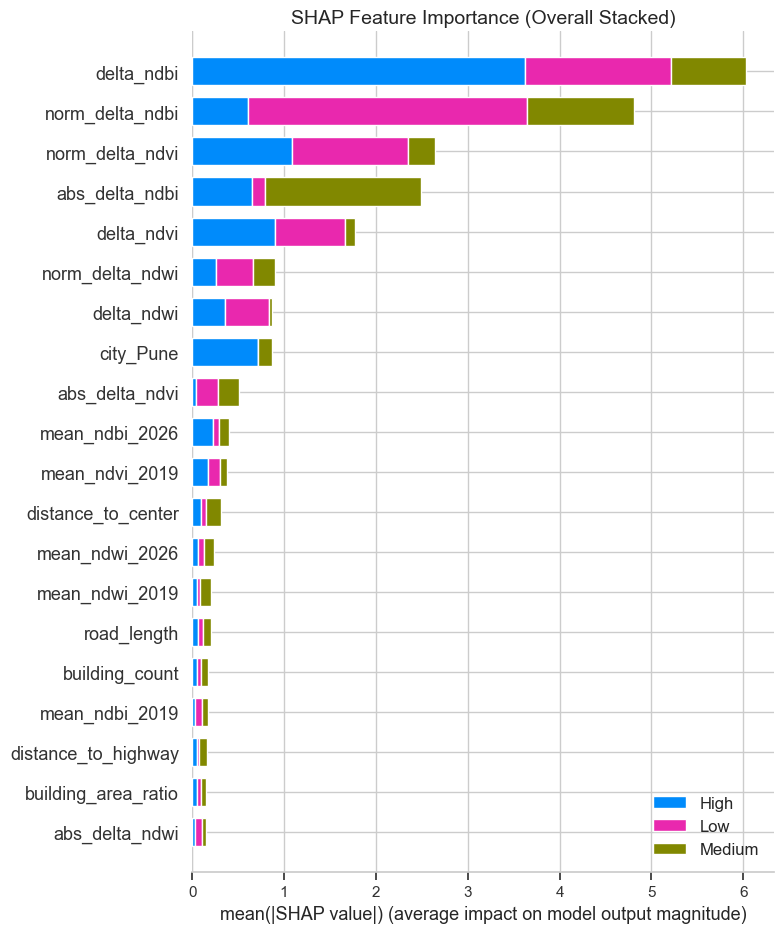

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_model, plot_type='bar', show=False, class_names=['High', 'Low', 'Medium'])
plt.title('SHAP Feature Importance (Overall Stacked)', fontsize=14)
plt.tight_layout()
plt.show()

### Top 20 Global Features Ranked by Mean Absolute SHAP

In [6]:
mean_abs_shap_global = np.mean(np.abs(shap_values), axis=(0, 2))
df_global_imp = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap_global
}).sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print('=== Top 20 Global Features ===')
for idx, row in df_global_imp.head(20).iterrows():
    print(f"  {idx+1:2d}. {row['Feature']:<25}: {row['Mean_Abs_SHAP']:.4f}")

=== Top 20 Global Features ===
   1. delta_ndbi               : 2.0107
   2. norm_delta_ndbi          : 1.6045
   3. norm_delta_ndvi          : 0.8811
   4. abs_delta_ndbi           : 0.8309
   5. delta_ndvi               : 0.5912
   6. norm_delta_ndwi          : 0.2993
   7. delta_ndwi               : 0.2904
   8. city_Pune                : 0.2881
   9. abs_delta_ndvi           : 0.1694
  10. mean_ndbi_2026           : 0.1342
  11. mean_ndvi_2019           : 0.1269
  12. distance_to_center       : 0.1061
  13. mean_ndwi_2026           : 0.0791
  14. mean_ndwi_2019           : 0.0684
  15. road_length              : 0.0671
  16. building_count           : 0.0590
  17. mean_ndbi_2019           : 0.0566
  18. distance_to_highway      : 0.0537
  19. building_area_ratio      : 0.0490
  20. abs_delta_ndwi           : 0.0488


## 4. City-Wise Top 10 Feature Drivers (High Growth class)

In [7]:
city_cols = {
    'Bengaluru': 'city_Bengaluru',
    'Hyderabad': 'city_Hyderabad',
    'Pune': 'city_Pune'
}

for city, col in city_cols.items():
    if col in X_test_model.columns:
        city_indices = np.where(X_test_model[col] == 1)[0]
        if len(city_indices) > 0:
            mean_abs_shap = np.mean(np.abs(shap_values[city_indices, :, 0]), axis=0)
            ranked = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)
            
            print(f'Top 10 Features Driving High Growth in {city}:')
            for rank, (feat, val) in enumerate(ranked[:10]):
                print(f'  {rank+1:2d}. {feat:<25}: {val:.4f}')
            print()

Top 10 Features Driving High Growth in Bengaluru:
   1. delta_ndbi               : 4.2198
   2. norm_delta_ndvi          : 0.9390
   3. delta_ndvi               : 0.8201
   4. norm_delta_ndbi          : 0.5918
   5. city_Pune                : 0.5274
   6. abs_delta_ndbi           : 0.4956
   7. delta_ndwi               : 0.3577
   8. mean_ndbi_2026           : 0.2801
   9. norm_delta_ndwi          : 0.2029
  10. mean_ndvi_2019           : 0.1657

Top 10 Features Driving High Growth in Hyderabad:
   1. delta_ndbi               : 3.9272
   2. norm_delta_ndvi          : 1.3527
   3. delta_ndvi               : 0.9764
   4. abs_delta_ndbi           : 0.6634
   5. norm_delta_ndbi          : 0.5449
   6. city_Pune                : 0.4092
   7. delta_ndwi               : 0.3448
   8. norm_delta_ndwi          : 0.2333
   9. mean_ndbi_2026           : 0.2012
  10. mean_ndvi_2019           : 0.1741

Top 10 Features Driving High Growth in Pune:
   1. delta_ndbi               : 2.3824
   2. city_Pu

## 5. Local Explainability (Waterfall & Force Plots)
We select representative samples predicted with 100% confidence for each class.

In [8]:
y_prob = model.predict_proba(X_test_model)
y_pred = model.predict(X_test_model)

high_indices = np.where(y_pred == 0)[0]
high_idx = high_indices[np.argmax(y_prob[high_indices, 0])]

low_indices = np.where(y_pred == 1)[0]
low_idx = low_indices[np.argmax(y_prob[low_indices, 1])]

med_indices = np.where(y_pred == 2)[0]
med_idx = med_indices[np.argmax(y_prob[med_indices, 2])]

local_samples = {
    'High Growth': (high_idx, 0, 'High'),
    'Low Growth': (low_idx, 1, 'Low'),
    'Medium Growth': (med_idx, 2, 'Medium')
}

### Local Feature Contribution Printouts

In [9]:
for label, (idx, code, key) in local_samples.items():
    print(f'=== Local Sample: {label} (Idx {idx}) ===')
    print(f'Prediction Probability: {y_prob[idx, code]:.4f}')
    contribs = []
    for f_idx, val in enumerate(shap_values[idx, :, code]):
        contribs.append((feature_names[f_idx], val, X_test_model.iloc[idx, f_idx]))
    contribs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    for rank, (feat, val, orig_val) in enumerate(contribs[:10]):
        direction = '(+)' if val > 0 else '(-)'
        print(f'  {rank+1:2d}. {feat:<25}: {val:+.4f} {direction:<5} [Original Val: {orig_val:.4f}]')
    print()

=== Local Sample: High Growth (Idx 523) ===
Prediction Probability: 1.0000
   1. delta_ndbi               : +3.4772 (+)   [Original Val: 1.7972]
   2. delta_ndvi               : +1.7074 (+)   [Original Val: -1.4510]
   3. abs_delta_ndbi           : +0.9999 (+)   [Original Val: 1.3561]
   4. norm_delta_ndbi          : +0.8319 (+)   [Original Val: 2.2769]
   5. delta_ndwi               : -0.4284 (-)   [Original Val: 0.8846]
   6. norm_delta_ndwi          : +0.3514 (+)   [Original Val: 0.4479]
   7. city_Pune                : +0.3280 (+)   [Original Val: 0.0000]
   8. norm_delta_ndvi          : +0.2989 (+)   [Original Val: 0.2534]
   9. mean_ndvi_2019           : +0.2826 (+)   [Original Val: 0.5292]
  10. distance_to_center       : +0.2147 (+)   [Original Val: 0.2899]

=== Local Sample: Low Growth (Idx 0) ===
Prediction Probability: 1.0000
   1. norm_delta_ndbi          : +2.7476 (+)   [Original Val: -1.4821]
   2. delta_ndbi               : +1.8395 (+)   [Original Val: -2.6980]
   3. nor

### SHAP Waterfall Plots

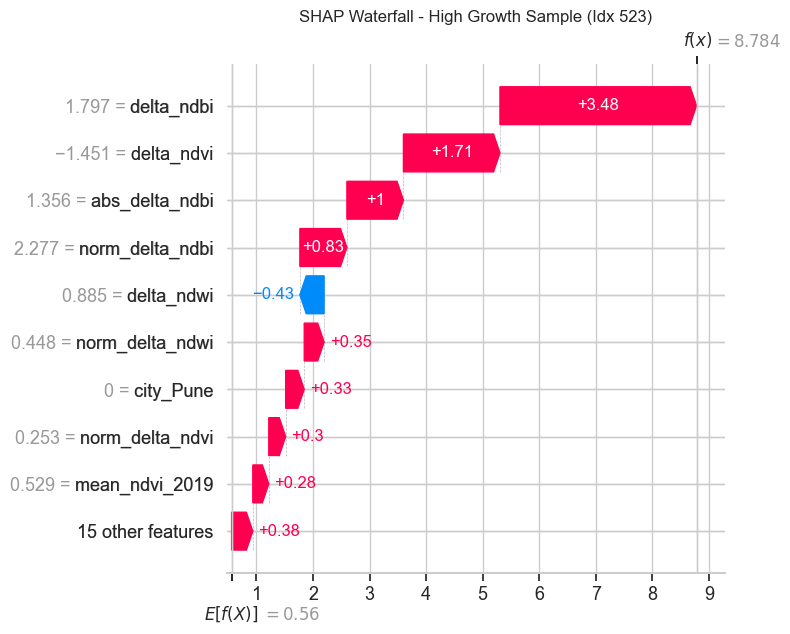

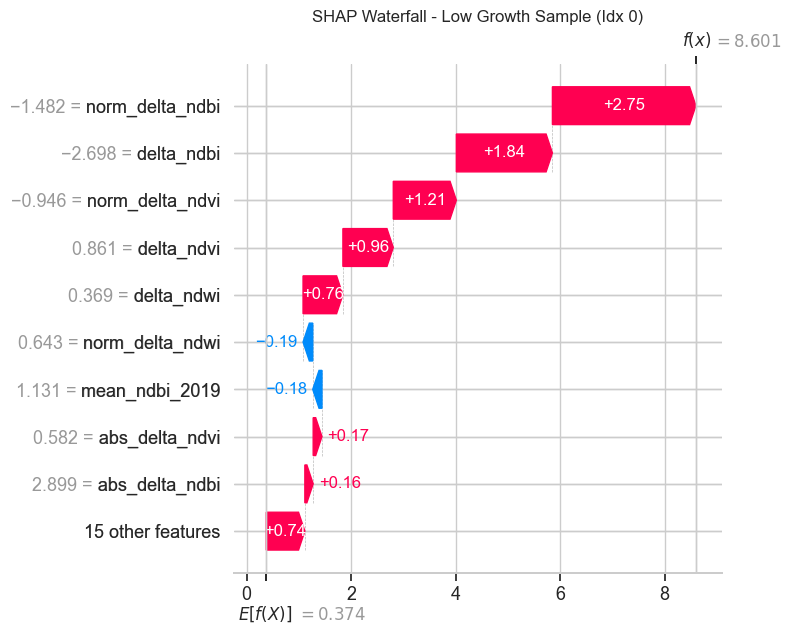

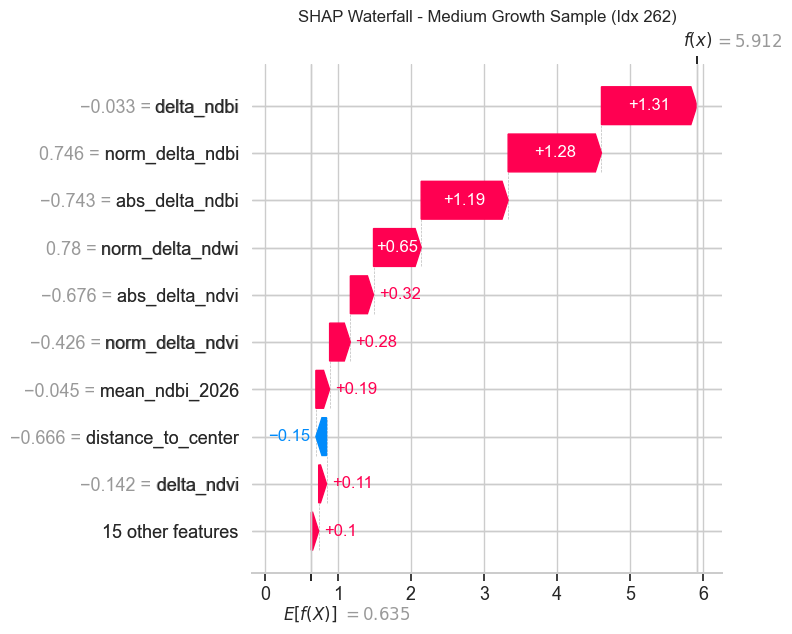

In [10]:
for label, (idx, code, key) in local_samples.items():
    exp_sample = shap.Explanation(
        values=shap_values[idx, :, code],
        base_values=explainer.expected_value[code],
        data=X_test_model.iloc[idx].values,
        feature_names=feature_names
    )
    
    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(exp_sample, show=False)
    plt.title(f'SHAP Waterfall - {label} Sample (Idx {idx})')
    plt.tight_layout()
    plt.show()

### SHAP Force Plots

In [11]:
# Load javascript library for inline rendering
shap.initjs()

print('High Growth Force Plot:')
shap.force_plot(explainer.expected_value[0], shap_values[high_idx, :, 0], X_test_model.iloc[high_idx])

High Growth Force Plot:


In [12]:
print('Low Growth Force Plot:')
shap.force_plot(explainer.expected_value[1], shap_values[low_idx, :, 1], X_test_model.iloc[low_idx])

Low Growth Force Plot:


In [13]:
print('Medium Growth Force Plot:')
shap.force_plot(explainer.expected_value[2], shap_values[med_idx, :, 2], X_test_model.iloc[med_idx])

Medium Growth Force Plot:
